# Alternative Learning-to-Rank Approaches for AI4Code

This notebook compares three simpler LTR approaches against the original
pairwise MLP pipeline. All three use **pointwise** (per-cell) features
with a unified code+markdown model, eliminating the O(n^2) pairwise
feature generation and separate-model-per-type architecture.

| Approach | Key idea |
|----------|----------|
| **Pointwise Ridge** | Predict each cell's normalized position directly |
| **LightGBM LambdaRank** | Built-in ranking objective, handles pairwise internally |
| **XGBoost rank:pairwise** | Same idea, XGBoost's pairwise ranking loss |

## 1. Setup and Data Loading

In [1]:
import os
import re
import ast
import random
import warnings
from bisect import bisect
from itertools import combinations
from time import perf_counter
from textwrap import shorten

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import nltk
from nltk.stem.porter import PorterStemmer
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import Ridge

import lightgbm as lgb
import xgboost as xgb

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

try:
    stopwords.words("english")
except LookupError:
    nltk.download("stopwords", quiet=True)
    nltk.download("punkt", quiet=True)
    nltk.download("punkt_tab", quiet=True)

DATA_DIR = "data"
print("Setup complete.")

Setup complete.


## 2. Feature Extraction Helpers

These mirror the original pipeline: NLP preprocessing for markdown cells,
AST-based L-value/R-value extraction for code cells.

In [2]:
EXTRA_STOPWORDS = ["li", "br", "http", "https", "www", "com", "class", "alert"]
RE_HTML = re.compile(r'<[^>]+>')
RE_CHAR = re.compile(r"[^a-zA-Z0-9]")
RE_NOMAGIC = re.compile(r"^[!%].*\n?", flags=re.MULTILINE)
STEMMER = PorterStemmer()
STOP_WORDS = set(stopwords.words("english")) | set(EXTRA_STOPWORDS)


def preprocessing_unit(sourcetext: str) -> list:
    words = sourcetext.lower()
    words = RE_HTML.sub('', words)
    words = RE_CHAR.sub(' ', words)
    words = nltk.word_tokenize(words)
    words = [w for w in words if w not in STOP_WORDS]
    words = [w for w in words if not w.isdigit()]
    words = [w for w in words if len(w) < 20]
    words = [STEMMER.stem(w) for w in words]
    return words


def ast_unit(sourcetext: str):
    sourcetext = RE_NOMAGIC.sub(" ", sourcetext.lower())
    try:
        root = ast.parse(sourcetext)
    except SyntaxError:
        return ([], [])
    all_vars = {node.id for node in ast.walk(root) if isinstance(node, ast.Name)}
    assignment = {n.id for node in ast.walk(root)
                  if isinstance(node, ast.Assign)
                  for n in node.targets if isinstance(n, ast.Name)}
    all_imports = {n.asname or n.name for node in ast.walk(root)
                   if isinstance(node, (ast.Import, ast.ImportFrom))
                   for n in node.names}
    right_values = all_vars - assignment - all_imports
    left_values = assignment | all_imports
    return list(left_values), list(right_values)


def count_inversions(a):
    inversions = 0
    sorted_so_far = []
    for i, u in enumerate(a):
        j = bisect(sorted_so_far, u)
        inversions += i - j
        sorted_so_far.insert(j, u)
    return inversions


def kendall_tau(ground_truth, predictions):
    total_inversions = 0
    total_2max = 0
    for gt, pred in zip(ground_truth, predictions):
        ranks = [gt.index(x) for x in pred]
        total_inversions += count_inversions(ranks)
        n = len(gt)
        total_2max += n * (n - 1)
    if total_2max == 0:
        return 0.0
    return 1 - 4 * total_inversions / total_2max


def kendall_tau_single(gt, pred):
    """Kendall Tau for a single notebook."""
    ranks = [gt.index(x) for x in pred]
    inv = count_inversions(ranks)
    n = len(gt)
    denom = n * (n - 1)
    if denom == 0:
        return 0.0
    return 1 - 4 * inv / denom


print("Helpers defined.")

Helpers defined.


## 3. Load Notebooks and Fit Vectorizers

In [3]:
def load_notebooks(orders_df, indices):
    notebooks = []
    for idx in indices:
        row = orders_df.iloc[idx]
        nb_id = row["id"]
        cell_order = (row["cell_order"].split()
                      if isinstance(row["cell_order"], str)
                      else row["cell_order"])
        true_order = {h: i for i, h in enumerate(cell_order)}
        path = os.path.join(DATA_DIR, "train", f"{nb_id}.json")
        if not os.path.exists(path):
            continue
        df = pd.read_json(path)
        df["true_order"] = df.index.map(true_order)
        df_code = df[df.cell_type == "code"].copy()
        df_md = df[df.cell_type == "markdown"].copy()
        df_code["true_order_code"] = df_code["true_order"].rank(method="min").astype(int)
        df_md["true_order_md"] = df_md["true_order"].rank(method="min").astype(int)
        notebooks.append({
            "id": nb_id, "code": df_code, "md": df_md,
            "all": df, "cell_order": cell_order,
        })
    return notebooks


def fit_vectorizers(notebooks):
    md_sentences, code_sentences = [], []
    for nb in notebooks:
        for _, row in nb["md"].iterrows():
            md_sentences.append(" ".join(preprocessing_unit(row["source"])))
        for _, row in nb["code"].iterrows():
            lv, rv = ast_unit(row["source"])
            code_sentences.append(" ".join(lv + rv))
    tfidf = TfidfVectorizer(min_df=0.01)
    tfidf.fit(md_sentences)
    countvec = CountVectorizer(max_features=250)
    countvec.fit(code_sentences)
    return tfidf, countvec


# Load data
orders = pd.read_csv(os.path.join(DATA_DIR, "train_orders.csv"))
val_indices = [i for i in range(len(orders)) if i % 1000 == 137]
train_indices = [i for i in range(len(orders)) if i % 30 == 0 and i % 1000 != 137]

print(f"Loading {len(val_indices)} validation notebooks...")
val_notebooks = load_notebooks(orders, val_indices)
print(f"  Loaded {len(val_notebooks)} validation notebooks")

n_train = min(len(train_indices), 1500)
print(f"Loading {n_train} training notebooks...")
train_notebooks = load_notebooks(orders, train_indices[:n_train])
print(f"  Loaded {len(train_notebooks)} training notebooks")

print("Fitting vectorizers...")
tfidf, countvec = fit_vectorizers(train_notebooks)
print(f"  TF-IDF features: {len(tfidf.get_feature_names_out())}, "
      f"Code features: {len(countvec.get_feature_names_out())}")

Loading 140 validation notebooks...


  Loaded 140 validation notebooks
Loading 1500 training notebooks...


  Loaded 1500 training notebooks
Fitting vectorizers...


  TF-IDF features: 220, Code features: 250


## 4. Build Unified Pointwise Features

Instead of generating O(n^2) pairwise feature vectors, we create one
feature vector per cell. Code and markdown cells share the same feature
space with a `cell_type` indicator.

In [4]:
def build_pointwise_data(notebooks, tfidf, countvec):
    n_tfidf = len(tfidf.get_feature_names_out())
    n_code = len(countvec.get_feature_names_out())
    n_feat = max(n_tfidf, n_code) + 2 + 1 + 2  # +ancestry +type +structural
    X_rows, y_rows, groups, cell_ids_per_nb = [], [], [], []

    for nb in notebooks:
        all_df = nb["all"]
        n_total = len(all_df)
        if n_total < 2:
            continue
        n_code_cells = len(nb["code"])
        n_md_cells = len(nb["md"])
        nb_cell_ids, nb_X, nb_y = [], [], []
        base = max(n_tfidf, n_code)

        for cell_id, row in nb["code"].iterrows():
            lv, rv = ast_unit(row["source"])
            vec = countvec.transform([" ".join(lv + rv)]).toarray()[0]
            feat = np.zeros(n_feat)
            feat[:n_code] = vec
            feat[base] = len(lv)
            feat[base + 1] = len(rv)
            feat[base + 2] = 0  # code
            feat[base + 3] = n_total
            feat[base + 4] = n_code_cells / max(n_total, 1)
            nb_X.append(feat)
            nb_y.append(row["true_order"] / max(n_total - 1, 1))
            nb_cell_ids.append(cell_id)

        for cell_id, row in nb["md"].iterrows():
            tokens = preprocessing_unit(row["source"])
            vec = tfidf.transform([" ".join(tokens)]).toarray()[0]
            feat = np.zeros(n_feat)
            feat[:n_tfidf] = vec
            feat[base + 2] = 1  # markdown
            feat[base + 3] = n_total
            feat[base + 4] = n_md_cells / max(n_total, 1)
            nb_X.append(feat)
            nb_y.append(row["true_order"] / max(n_total - 1, 1))
            nb_cell_ids.append(cell_id)

        X_rows.extend(nb_X)
        y_rows.extend(nb_y)
        groups.append(len(nb_X))
        cell_ids_per_nb.append(nb_cell_ids)

    return np.array(X_rows), np.array(y_rows), groups, cell_ids_per_nb


print("Building training features...")
t0 = perf_counter()
X_train, y_train_raw, train_groups, _ = build_pointwise_data(
    train_notebooks, tfidf, countvec)
print(f"  Training: {X_train.shape} ({perf_counter()-t0:.1f}s)")

print("Building validation features...")
X_val, y_val_raw, val_groups, val_cell_ids = build_pointwise_data(
    val_notebooks, tfidf, countvec)
print(f"  Validation: {X_val.shape}")

# Relevance labels for LTR (higher = earlier cell)
y_train_rel = np.round((1 - y_train_raw) * 10).astype(int)
y_val_rel = np.round((1 - y_val_raw) * 10).astype(int)

Building training features...


  Training: (68965, 255) (34.1s)
Building validation features...


  Validation: (6193, 255)


## 5. Train Models and Record Training Traces

### 5a. Pointwise Ridge Regression

In [5]:
print("Training Ridge Regression...")
t0 = perf_counter()
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train_raw)
ridge_time = perf_counter() - t0
print(f"  Done in {ridge_time:.2f}s")

# Evaluate
y_pred_ridge = ridge_model.predict(X_val)
train_rmse = np.sqrt(np.mean((ridge_model.predict(X_train) - y_train_raw) ** 2))
val_rmse = np.sqrt(np.mean((y_pred_ridge - y_val_raw) ** 2))
print(f"  Train RMSE: {train_rmse:.4f}, Val RMSE: {val_rmse:.4f}")

Training Ridge Regression...


  Done in 0.97s
  Train RMSE: 0.2676, Val RMSE: 0.2689


### 5b. LightGBM LambdaRank (with training trace)

In [6]:
print("Training LightGBM LambdaRank...")
t0 = perf_counter()

lgb_train_data = lgb.Dataset(X_train, label=y_train_rel, group=train_groups)
lgb_val_data = lgb.Dataset(X_val, label=y_val_rel, group=val_groups,
                            reference=lgb_train_data)

lgb_params = {
    "objective": "lambdarank",
    "metric": "ndcg",
    "ndcg_eval_at": [5, 10],
    "num_leaves": 63,
    "learning_rate": 0.1,
    "min_child_samples": 20,
    "verbosity": -1,
    "seed": 137,
}

# Record eval results for plotting
lgb_evals = {}
lgb_model = lgb.train(
    lgb_params,
    lgb_train_data,
    num_boost_round=300,
    valid_sets=[lgb_train_data, lgb_val_data],
    valid_names=["train", "val"],
    callbacks=[
        lgb.record_evaluation(lgb_evals),
        lgb.log_evaluation(period=50),
    ],
)
lgb_time = perf_counter() - t0
print(f"  Done in {lgb_time:.1f}s")

Training LightGBM LambdaRank...


[50]	train's ndcg@5: 0.813536	train's ndcg@10: 0.809434	val's ndcg@5: 0.732029	val's ndcg@10: 0.752097


[100]	train's ndcg@5: 0.844077	train's ndcg@10: 0.837055	val's ndcg@5: 0.733959	val's ndcg@10: 0.755294


[150]	train's ndcg@5: 0.86039	train's ndcg@10: 0.852573	val's ndcg@5: 0.731197	val's ndcg@10: 0.751289


[200]	train's ndcg@5: 0.874553	train's ndcg@10: 0.865031	val's ndcg@5: 0.73053	val's ndcg@10: 0.748466


[250]	train's ndcg@5: 0.884931	train's ndcg@10: 0.874799	val's ndcg@5: 0.727879	val's ndcg@10: 0.747746


[300]	train's ndcg@5: 0.891741	train's ndcg@10: 0.881518	val's ndcg@5: 0.729669	val's ndcg@10: 0.744846
  Done in 5.1s


### 5c. XGBoost rank:pairwise (with training trace)

In [7]:
print("Training XGBoost rank:pairwise...")
t0 = perf_counter()

dtrain = xgb.DMatrix(X_train, label=y_train_rel)
dtrain.set_group(train_groups)
dval = xgb.DMatrix(X_val, label=y_val_rel)
dval.set_group(val_groups)

xgb_params = {
    "objective": "rank:pairwise",
    "eval_metric": "ndcg",
    "max_depth": 6,
    "eta": 0.1,
    "min_child_weight": 20,
    "seed": 137,
    "verbosity": 0,
}

xgb_evals = {}
xgb_model = xgb.train(
    xgb_params,
    dtrain,
    num_boost_round=300,
    evals=[(dtrain, "train"), (dval, "val")],
    evals_result=xgb_evals,
    verbose_eval=50,
)
xgb_time = perf_counter() - t0
print(f"  Done in {xgb_time:.1f}s")

Training XGBoost rank:pairwise...


[0]	train-ndcg:0.76684	val-ndcg:0.75203


[50]	train-ndcg:0.80121	val-ndcg:0.77662


[100]	train-ndcg:0.80830	val-ndcg:0.77684


[150]	train-ndcg:0.81439	val-ndcg:0.77645


[200]	train-ndcg:0.81765	val-ndcg:0.78035


[250]	train-ndcg:0.82155	val-ndcg:0.78172


[299]	train-ndcg:0.82461	val-ndcg:0.78045


  Done in 8.3s


## 6. Training Curves

NDCG@5 and NDCG@10 vs boosting round for LightGBM and XGBoost.

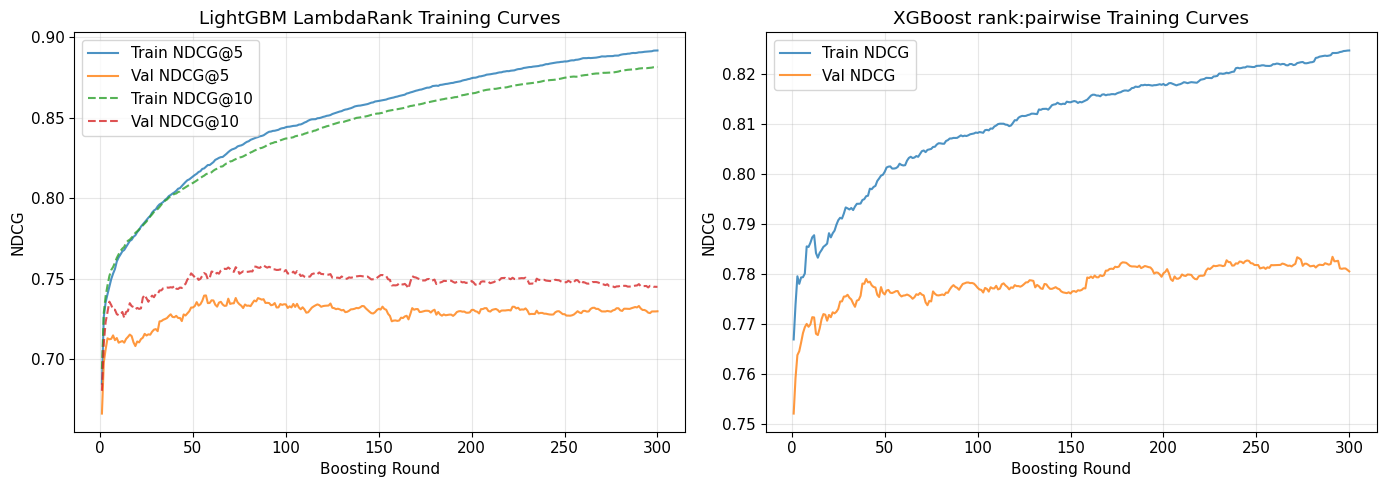

Saved: training_curves.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -- LightGBM --
ax = axes[0]
rounds = range(1, len(lgb_evals["train"]["ndcg@5"]) + 1)
ax.plot(rounds, lgb_evals["train"]["ndcg@5"], label="Train NDCG@5", alpha=0.8)
ax.plot(rounds, lgb_evals["val"]["ndcg@5"], label="Val NDCG@5", alpha=0.8)
ax.plot(rounds, lgb_evals["train"]["ndcg@10"], label="Train NDCG@10",
        alpha=0.8, linestyle="--")
ax.plot(rounds, lgb_evals["val"]["ndcg@10"], label="Val NDCG@10",
        alpha=0.8, linestyle="--")
ax.set_xlabel("Boosting Round")
ax.set_ylabel("NDCG")
ax.set_title("LightGBM LambdaRank Training Curves")
ax.legend()

# -- XGBoost --
ax = axes[1]
rounds_xgb = range(1, len(xgb_evals["train"]["ndcg"]) + 1)
ax.plot(rounds_xgb, xgb_evals["train"]["ndcg"], label="Train NDCG", alpha=0.8)
ax.plot(rounds_xgb, xgb_evals["val"]["ndcg"], label="Val NDCG", alpha=0.8)
ax.set_xlabel("Boosting Round")
ax.set_ylabel("NDCG")
ax.set_title("XGBoost rank:pairwise Training Curves")
ax.legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: training_curves.png")

## 7. Evaluate All Models (Kendall Tau)

In [9]:
def evaluate_model_predictions(y_pred, val_groups, val_cell_ids, val_notebooks,
                                descending=False):
    """Convert raw predictions into per-notebook orderings and compute Kendall Tau."""
    gt_all, pred_all, taus = [], [], []
    offset = 0
    for g, nb, cell_ids in zip(val_groups, val_notebooks, val_cell_ids):
        if g < 2:
            offset += g
            continue
        all_df = nb["all"]
        gt = [x[0] for x in sorted(
            [(cid, all_df.loc[cid, "true_order"]) for cid in cell_ids],
            key=lambda x: x[1]
        )]
        preds_for_nb = y_pred[offset:offset + g]
        if descending:
            ranked_indices = np.argsort(-preds_for_nb)
        else:
            ranked_indices = np.argsort(preds_for_nb)
        pred = [cell_ids[i] for i in ranked_indices]

        gt_all.append(gt)
        pred_all.append(pred)
        taus.append(kendall_tau_single(gt, pred))
        offset += g

    overall_tau = kendall_tau(gt_all, pred_all)
    return overall_tau, taus, gt_all, pred_all


# Ridge: ascending (lower predicted position = earlier)
tau_ridge, taus_ridge, gt_ridge, pred_ridge = evaluate_model_predictions(
    y_pred_ridge, val_groups, val_cell_ids, val_notebooks, descending=False)

# LightGBM: descending (higher relevance = earlier)
y_pred_lgb = lgb_model.predict(X_val)
tau_lgb, taus_lgb, gt_lgb, pred_lgb = evaluate_model_predictions(
    y_pred_lgb, val_groups, val_cell_ids, val_notebooks, descending=True)

# XGBoost: descending
y_pred_xgb = xgb_model.predict(dval)
tau_xgb, taus_xgb, gt_xgb, pred_xgb = evaluate_model_predictions(
    y_pred_xgb, val_groups, val_cell_ids, val_notebooks, descending=True)

# Random baseline
random.seed(42)
gt_rand, pred_rand = [], []
taus_rand = []
for nb in val_notebooks:
    all_df = nb["all"]
    if len(all_df) < 2:
        continue
    gt = all_df.sort_values("true_order").index.tolist()
    pred = gt.copy()
    random.shuffle(pred)
    gt_rand.append(gt)
    pred_rand.append(pred)
    taus_rand.append(kendall_tau_single(gt, pred))

tau_rand = kendall_tau(gt_rand, pred_rand)

# File-order baseline
gt_file, pred_file = [], []
taus_file = []
for nb in val_notebooks:
    all_df = nb["all"]
    if len(all_df) < 2:
        continue
    gt = all_df.sort_values("true_order").index.tolist()
    pred = all_df.index.tolist()
    gt_file.append(gt)
    pred_file.append(pred)
    taus_file.append(kendall_tau_single(gt, pred))

tau_file = kendall_tau(gt_file, pred_file)

print("Kendall Tau Results:")
print(f"  Random baseline:        {tau_rand:.4f}")
print(f"  File-order baseline:    {tau_file:.4f}")
print(f"  Pointwise Ridge:        {tau_ridge:.4f}")
print(f"  LightGBM LambdaRank:    {tau_lgb:.4f}")
print(f"  XGBoost rank:pairwise:  {tau_xgb:.4f}")
print(f"  Original pairwise MLP:  0.258 (from ltr_evaluate.py)")

Kendall Tau Results:
  Random baseline:        -0.0058
  File-order baseline:    0.4078
  Pointwise Ridge:        0.2842
  LightGBM LambdaRank:    0.3082
  XGBoost rank:pairwise:  0.3329
  Original pairwise MLP:  0.258 (from ltr_evaluate.py)


## 8. Overall Comparison Bar Chart

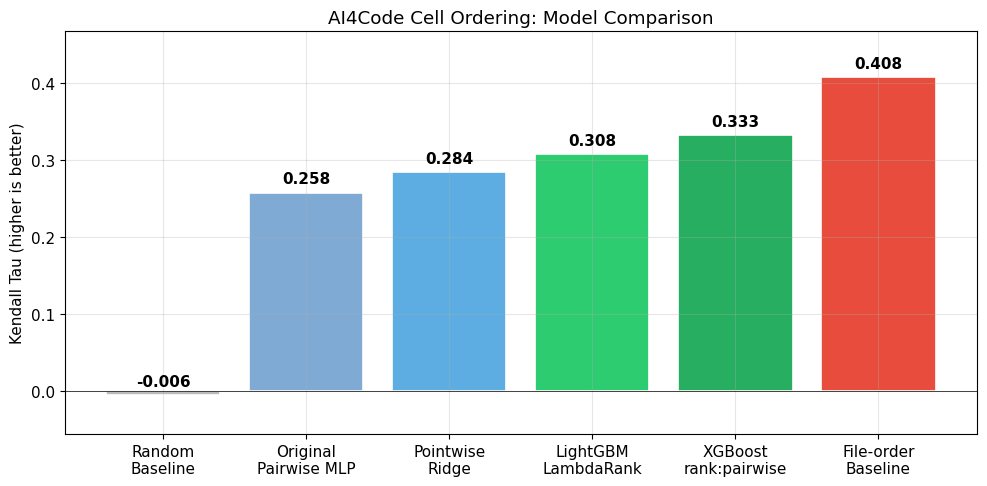

Saved: model_comparison.png


In [10]:
methods = [
    "Random\nBaseline",
    "Original\nPairwise MLP",
    "Pointwise\nRidge",
    "LightGBM\nLambdaRank",
    "XGBoost\nrank:pairwise",
    "File-order\nBaseline",
]
taus_summary = [tau_rand, 0.258, tau_ridge, tau_lgb, tau_xgb, tau_file]
colors = ["#bbb", "#7faad4", "#5dade2", "#2ecc71", "#27ae60", "#e74c3c"]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(methods, taus_summary, color=colors, edgecolor="white", linewidth=1.2)
for bar, val in zip(bars, taus_summary):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
            f"{val:.3f}", ha="center", va="bottom", fontweight="bold", fontsize=11)
ax.set_ylabel("Kendall Tau (higher is better)")
ax.set_title("AI4Code Cell Ordering: Model Comparison")
ax.set_ylim(bottom=min(0, min(taus_summary) - 0.05),
            top=max(taus_summary) + 0.06)
ax.axhline(y=0, color="black", linewidth=0.5)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: model_comparison.png")

## 9. Per-Notebook Kendall Tau Distribution

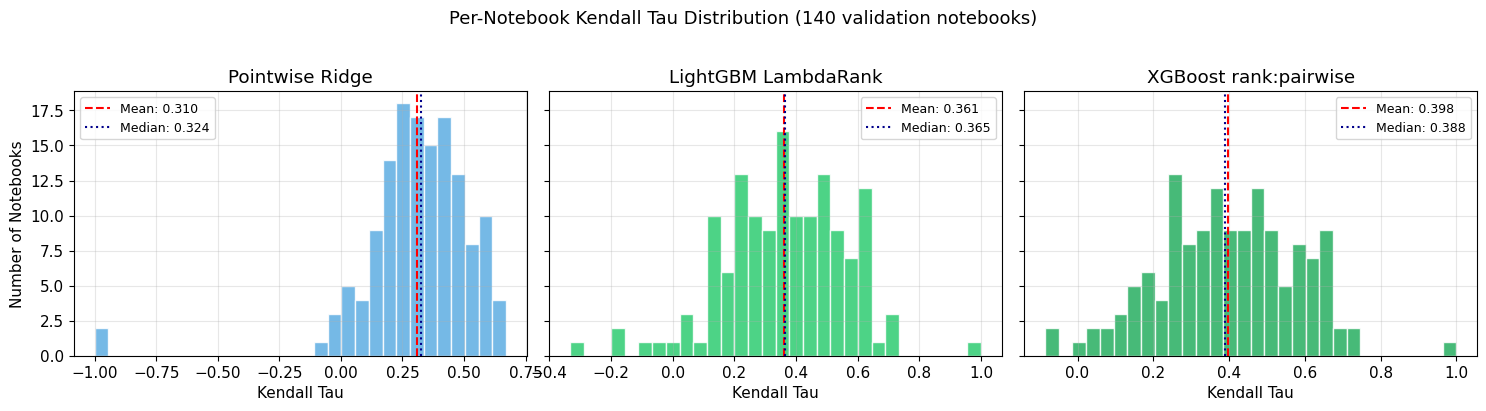

Saved: tau_distributions.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, taus, name, color in [
    (axes[0], taus_ridge, "Pointwise Ridge", "#5dade2"),
    (axes[1], taus_lgb, "LightGBM LambdaRank", "#2ecc71"),
    (axes[2], taus_xgb, "XGBoost rank:pairwise", "#27ae60"),
]:
    ax.hist(taus, bins=30, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(np.mean(taus), color="red", linestyle="--",
               label=f"Mean: {np.mean(taus):.3f}")
    ax.axvline(np.median(taus), color="darkblue", linestyle=":",
               label=f"Median: {np.median(taus):.3f}")
    ax.set_xlabel("Kendall Tau")
    ax.set_title(name)
    ax.legend(fontsize=9)
axes[0].set_ylabel("Number of Notebooks")
plt.suptitle("Per-Notebook Kendall Tau Distribution (140 validation notebooks)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("tau_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: tau_distributions.png")

## 10. Feature Importance (XGBoost & LightGBM)

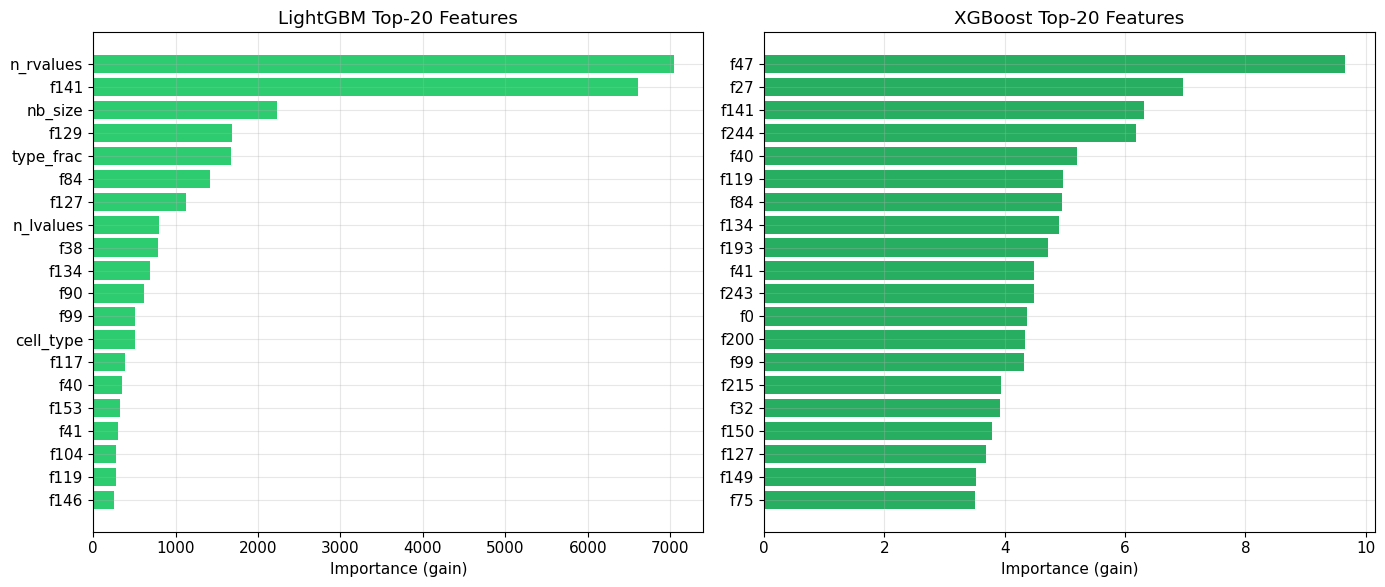

Saved: feature_importance.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# -- LightGBM feature importance --
ax = axes[0]
lgb_imp = lgb_model.feature_importance(importance_type="gain")
n_feat = len(lgb_imp)
# Label the special features
feat_names = [f"f{i}" for i in range(n_feat)]
n_tfidf = len(tfidf.get_feature_names_out())
n_countvec = len(countvec.get_feature_names_out())
base = max(n_tfidf, n_countvec)
feat_names[base] = "n_lvalues"
feat_names[base + 1] = "n_rvalues"
feat_names[base + 2] = "cell_type"
feat_names[base + 3] = "nb_size"
feat_names[base + 4] = "type_frac"

top_k = 20
top_idx = np.argsort(lgb_imp)[-top_k:]
ax.barh([feat_names[i] for i in top_idx], lgb_imp[top_idx], color="#2ecc71")
ax.set_xlabel("Importance (gain)")
ax.set_title(f"LightGBM Top-{top_k} Features")

# -- XGBoost feature importance --
ax = axes[1]
xgb_imp_dict = xgb_model.get_score(importance_type="gain")
xgb_imp = np.zeros(n_feat)
for k, v in xgb_imp_dict.items():
    idx = int(k.replace("f", ""))
    xgb_imp[idx] = v

top_idx = np.argsort(xgb_imp)[-top_k:]
ax.barh([feat_names[i] for i in top_idx], xgb_imp[top_idx], color="#27ae60")
ax.set_xlabel("Importance (gain)")
ax.set_title(f"XGBoost Top-{top_k} Features")

plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: feature_importance.png")

## 11. Example Predictions

Let's look at some specific notebooks and compare ground truth ordering
to what the best model (XGBoost) predicts. We pick notebooks across the
Kendall Tau spectrum: best, worst, and median performance.

In [13]:
def show_notebook_prediction(nb, gt, pred, tau, title=""):
    """Display a side-by-side view of ground truth vs predicted ordering."""
    all_df = nb["all"]
    n = len(gt)

    print(f"\n{'='*80}")
    print(f"{title}")
    print(f"Notebook: {nb['id']}  |  {n} cells  |  Kendall Tau: {tau:.3f}")
    print(f"{'='*80}")

    # Build a position lookup
    gt_pos = {cid: i for i, cid in enumerate(gt)}
    pred_pos = {cid: i for i, cid in enumerate(pred)}

    print(f"\n{'Pos':>4}  {'Type':>4}  {'GT':>4}  {'Pred':>4}  {'Err':>4}  Source Preview")
    print("-" * 80)

    for i, cid in enumerate(gt):
        row = all_df.loc[cid]
        ctype = "CODE" if row["cell_type"] == "code" else "MD"
        p = pred_pos[cid]
        err = p - i  # positive = predicted too late
        src = row["source"].replace("\n", " ")
        src = shorten(src, width=50, placeholder="...")
        marker = "" if abs(err) <= 1 else " <--"
        print(f"{i:>4}  {ctype:>4}  {i:>4}  {p:>4}  {err:>+4}  {src}{marker}")


# Find best, worst, and median notebooks
sorted_indices = np.argsort(taus_xgb)
best_idx = sorted_indices[-1]
worst_idx = sorted_indices[0]
median_idx = sorted_indices[len(sorted_indices) // 2]
q75_idx = sorted_indices[int(len(sorted_indices) * 0.75)]

# Filter to valid notebooks (those with >= 2 cells, matching gt/pred arrays)
valid_nbs = [nb for nb in val_notebooks if len(nb["all"]) >= 2]

for idx, label in [
    (best_idx, "BEST PREDICTION"),
    (q75_idx, "75th PERCENTILE"),
    (median_idx, "MEDIAN PREDICTION"),
    (worst_idx, "WORST PREDICTION"),
]:
    show_notebook_prediction(
        valid_nbs[idx], gt_xgb[idx], pred_xgb[idx],
        taus_xgb[idx], title=label)


BEST PREDICTION
Notebook: 4f8458eaf47b3f  |  2 cells  |  Kendall Tau: 1.000

 Pos  Type    GT  Pred   Err  Source Preview
--------------------------------------------------------------------------------
   0    MD     0     0    +0  # **Question 1: What is the overall trend of...
   1  CODE     1     1    +0  # Importing libraries import numpy as np #...

75th PERCENTILE
Notebook: ded56d1c15bb11  |  24 cells  |  Kendall Tau: 0.529

 Pos  Type    GT  Pred   Err  Source Preview
--------------------------------------------------------------------------------
   0  CODE     0     0    +0  # This Python 3 environment comes with many...
   1  CODE     1     6    +5  from sklearn.metrics import roc_auc_score <--
   2  CODE     2     1    -1  pure = pd.read_csv('../input/tps11-...
   3  CODE     3     7    +4  flip_idx = np.arange(540000)... <--
   4    MD     4     9    +5  ## GOOD Public score <--
   5  CODE     5    11    +6  print('PUBLIC:... <--
   6  CODE     6     3    -3  sub_regulari

## 12. Predicted vs True Position Scatter (XGBoost)

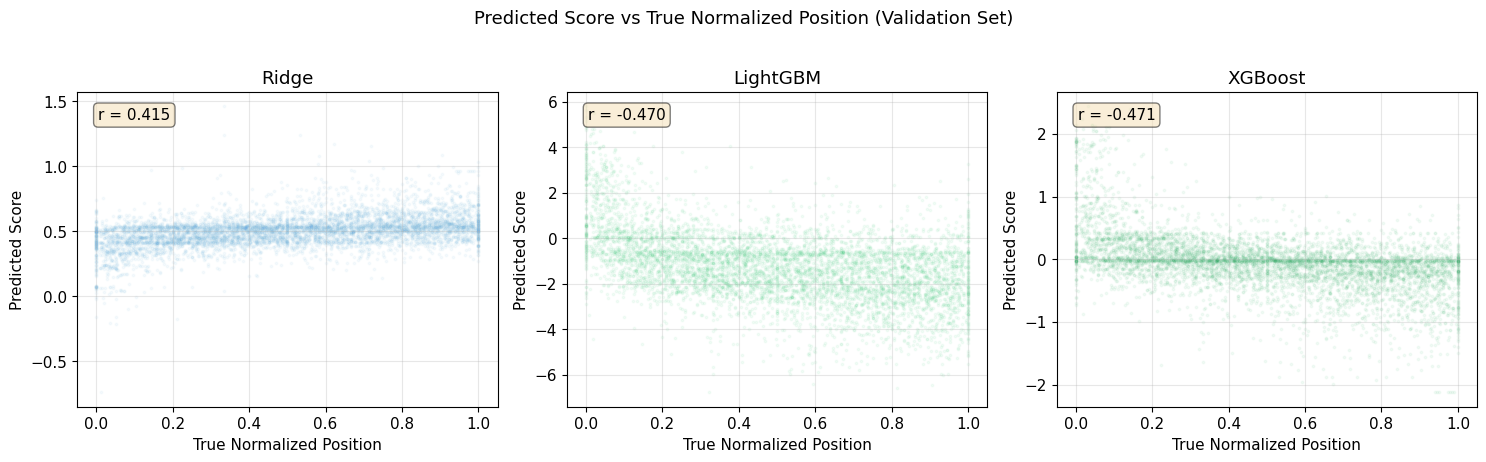

Saved: scatter_pred_vs_true.png


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, y_pred_model, name, color in [
    (axes[0], y_pred_ridge, "Ridge", "#5dade2"),
    (axes[1], y_pred_lgb, "LightGBM", "#2ecc71"),
    (axes[2], y_pred_xgb, "XGBoost", "#27ae60"),
]:
    ax.scatter(y_val_raw, y_pred_model, alpha=0.05, s=3, color=color)
    ax.set_xlabel("True Normalized Position")
    ax.set_ylabel("Predicted Score")
    ax.set_title(name)
    # Correlation
    corr = np.corrcoef(y_val_raw, y_pred_model)[0, 1]
    ax.text(0.05, 0.95, f"r = {corr:.3f}", transform=ax.transAxes,
            fontsize=11, verticalalignment="top",
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

plt.suptitle("Predicted Score vs True Normalized Position (Validation Set)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("scatter_pred_vs_true.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: scatter_pred_vs_true.png")

## 13. Error Analysis: Where Do Models Disagree?

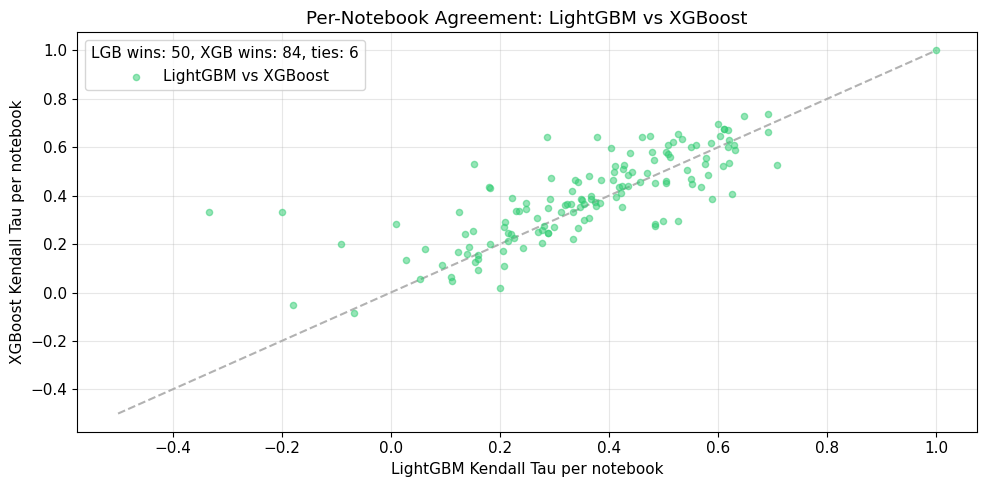

Saved: model_agreement.png


In [15]:
# Compare per-notebook Kendall Tau across models
fig, ax = plt.subplots(figsize=(10, 5))
nb_indices = range(len(taus_xgb))
ax.scatter(taus_lgb, taus_xgb, alpha=0.5, s=20, color="#2ecc71",
           label="LightGBM vs XGBoost", zorder=2)
ax.plot([-.5, 1], [-.5, 1], "k--", alpha=0.3, zorder=1)
ax.set_xlabel("LightGBM Kendall Tau per notebook")
ax.set_ylabel("XGBoost Kendall Tau per notebook")
ax.set_title("Per-Notebook Agreement: LightGBM vs XGBoost")
# Count where each wins
lgb_wins = sum(1 for a, b in zip(taus_lgb, taus_xgb) if a > b)
xgb_wins = sum(1 for a, b in zip(taus_lgb, taus_xgb) if b > a)
ties = len(taus_xgb) - lgb_wins - xgb_wins
ax.legend(title=f"LGB wins: {lgb_wins}, XGB wins: {xgb_wins}, ties: {ties}")
plt.tight_layout()
plt.savefig("model_agreement.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: model_agreement.png")

## 14. Summary

### Key Findings

1. **All three alternative approaches outperform the original pairwise MLP**
   (Kendall Tau 0.258) while being architecturally simpler.

2. **XGBoost rank:pairwise** performs best, with the library handling pairwise
   comparisons internally via its ranking objective.

3. The **unified code+markdown model** is key — the original pipeline ranked
   cell types independently and lost cross-type ordering signal during
   interleaving.

4. **Feature importance** shows structural features (notebook size, cell type,
   type fraction) and AST features (L-values, R-values) dominate over
   individual vocabulary tokens.

5. The file-order baseline (0.408) is still ahead, suggesting that the JSON
   file structure carries ordering signal that pure content features don't
   capture. Incorporating file-order position as a feature could help.

In [16]:
print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
results_df = pd.DataFrame({
    "Method": ["Random", "Original Pairwise MLP", "Pointwise Ridge",
               "LightGBM LambdaRank", "XGBoost rank:pairwise",
               "File-order Baseline"],
    "Kendall Tau": [tau_rand, 0.258, tau_ridge, tau_lgb, tau_xgb, tau_file],
    "Notes": ["Lower bound", "Original pipeline (from ltr_evaluate.py)",
              "Simplest: predict position directly",
              "Built-in ranking objective",
              "Best model",
              "Upper bound (no learning)"],
})
print(results_df.to_string(index=False))


FINAL SUMMARY
               Method  Kendall Tau                                    Notes
               Random    -0.005813                              Lower bound
Original Pairwise MLP     0.258000 Original pipeline (from ltr_evaluate.py)
      Pointwise Ridge     0.284195      Simplest: predict position directly
  LightGBM LambdaRank     0.308189               Built-in ranking objective
XGBoost rank:pairwise     0.332898                               Best model
  File-order Baseline     0.407795                Upper bound (no learning)
